In [1]:
import os
import json
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tqdm import tqdm
import matplotlib.pyplot as plt
import re
import shutil
import random
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
import json
import numpy as np
from shapely.geometry import Polygon
import math
import os
import tensorflow as tf

# -------------------------
# 1) Mejor get_image_paths_and_json_paths (devuelve pares ordenados)
# -------------------------
def get_image_paths_and_json_paths(data_dir):
    pairs = []
    for filename in os.listdir(data_dir):
        if filename.lower().endswith(".jpg") or filename.lower().endswith(".jpeg") or filename.lower().endswith(".png"):
            img_path = os.path.join(data_dir, filename)
            json_path = os.path.join(data_dir, os.path.splitext(filename)[0] + ".json")
            if os.path.exists(json_path):
                pairs.append((img_path, json_path))
    # Ordenar por nombre base para consistencia
    pairs.sort(key=lambda p: os.path.basename(p[0]))
    image_paths = [p[0] for p in pairs]
    json_paths  = [p[1] for p in pairs]
    return image_paths, json_paths

# -------------------------
# 2) get_oriented_bbox_from_xywh_json (mantengo tu lógica, añado clipping)
# -------------------------
def get_oriented_bbox_from_xywh_json(json_data, image_width, image_height):
    """
    json_data: lista de objetos tal como muestras.
    image_width, image_height: dimensiones REALES de la imagen donde están las anotaciones.
    Retorna: [cx_norm, cy_norm, w_norm, h_norm, angle_norm] dtype float32
    """
    all_polygons = []
    for obj in json_data:
        if obj.get("char", "").strip() == "" or "bbox_xywh" not in obj:
            continue
        x, y, w, h = obj["bbox_xywh"]
        corners = [(x, y), (x + w, y), (x + w, y + h), (x, y + h)]
        all_polygons.append(Polygon(corners))
    if not all_polygons:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)

    merged_polygon = all_polygons[0]
    for i in range(1, len(all_polygons)):
        merged_polygon = merged_polygon.union(all_polygons[i])

    min_rect = merged_polygon.minimum_rotated_rectangle
    coords = np.array(min_rect.exterior.coords[:-1])

    center_x = np.mean(coords[:, 0])
    center_y = np.mean(coords[:, 1])

    edge1_len = np.linalg.norm(coords[0] - coords[1])
    edge2_len = np.linalg.norm(coords[1] - coords[2])

    if edge1_len > edge2_len:
        width = edge1_len
        height = edge2_len
        angle_rad = math.atan2(coords[1][1] - coords[0][1], coords[1][0] - coords[0][0])
    else:
        width = edge2_len
        height = edge1_len
        angle_rad = math.atan2(coords[2][1] - coords[1][1], coords[2][0] - coords[1][0])

    # Normalizar ángulo a [-pi/2, pi/2]
    if angle_rad > math.pi / 2:
        angle_rad -= math.pi
    elif angle_rad < -math.pi / 2:
        angle_rad += math.pi

    # Normalizar en base a dimensiones pasadas (IMPORTANTE: usar dimensiones REALES)
    norm_center_x = center_x / float(image_width)
    norm_center_y = center_y / float(image_height)
    norm_width = width / float(image_width)
    norm_height = height / float(image_height)
    norm_angle = angle_rad / (math.pi / 2.0)

    # Seguridad: clip a [0,1] para centros y tamaños razonables,
    # y clip de ángulo a [-1,1]
    norm_center_x = float(np.clip(norm_center_x, 0.0, 1.0))
    norm_center_y = float(np.clip(norm_center_y, 0.0, 1.0))
    norm_width  = float(np.clip(norm_width, 0.0, 1.0))
    norm_height = float(np.clip(norm_height, 0.0, 1.0))
    norm_angle  = float(np.clip(norm_angle, -1.0, 1.0))

    return np.array([norm_center_x, norm_center_y, norm_width, norm_height, norm_angle], dtype=np.float32)

# -------------------------
# 3) load_and_preprocess_sample: usar dimensiones originales para normalizar
# -------------------------
def load_and_preprocess_sample(image_path, json_path, target_size=(150, 300)):
    """
    - Decodifica imagen, obtiene tamaño original.
    - Llama a py_function para parsear JSON usando dimensiones originales.
    - Luego redimensiona la imagen a target_size.
    - Retorna image_resized (H,W,1) float32 en [0,1] y bbox_target (5,)
    """
    # leer archivo (como tensor)
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=1)  # original size and type
    orig_shape = tf.shape(img)
    orig_h = tf.cast(orig_shape[0], tf.int32)
    orig_w = tf.cast(orig_shape[1], tf.int32)

    # Usar tf.py_function para leer JSON y calcular bbox con las dimensiones ORIGINALES
    def _parse_json_and_get_bbox(json_file_path, ow, oh):
        json_path_str = json_file_path.numpy().decode('utf-8')
        ow_i = int(ow)
        oh_i = int(oh)
        with open(json_path_str, 'r') as f:
            json_data = json.load(f)
        return get_oriented_bbox_from_xywh_json(json_data, ow_i, oh_i)

    bbox_target = tf.py_function(
        func=_parse_json_and_get_bbox,
        inp=[json_path, orig_w, orig_h],
        Tout=tf.float32
    )
    bbox_target.set_shape([5])

    # Ahora redimensionar la imagen al tamaño objetivo (height, width)
    img_resized = tf.image.resize(img, [target_size[0], target_size[1]])
    img_resized = tf.cast(img_resized, tf.float32) / 255.0

    return img_resized, bbox_target

# -------------------------
# 4) wrapper create_dataset (usa la nueva load_and_preprocess_sample con target size)
# -------------------------
def create_dataset_from_paths(image_paths, json_paths, batch_size, target_size=(150,300), shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, json_paths))
    map_fn = lambda im_p, js_p: tf.py_function(
        func=lambda a,b: load_and_preprocess_sample(a,b,target_size),
        inp=[im_p, js_p],
        Tout=(tf.float32, tf.float32)
    )
    # Alternatively (more efficient) use dataset.map with a function that decodes image inside:
    ds = ds.map(lambda im_p, js_p: load_and_preprocess_sample(im_p, js_p, target_size),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [4]:
import cv2
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon

def denormalize_bbox(norm_bbox, image_width, image_height):
    cx = norm_bbox[0] * image_width
    cy = norm_bbox[1] * image_height
    w  = norm_bbox[2] * image_width
    h  = norm_bbox[3] * image_height
    angle = norm_bbox[4] * (math.pi / 2.0)
    return np.array([cx, cy, w, h, angle], dtype=np.float32)

def bbox_to_corners(cx, cy, w, h, angle_rad):
    # devuelve np.array([[x1,y1],...]) tl,tr,br,bl
    corners = np.array([
        [-w/2, -h/2],
        [ w/2, -h/2],
        [ w/2,  h/2],
        [-w/2,  h/2],
    ], dtype=np.float32)
    R = np.array([[math.cos(angle_rad), -math.sin(angle_rad)],
                  [math.sin(angle_rad),  math.cos(angle_rad)]], dtype=np.float32)
    rotated = corners @ R.T
    translated = rotated + np.array([cx, cy], dtype=np.float32)
    return translated

def plot_sample_with_gt(image_resized, norm_bbox, title="sample"):
    h, w = image_resized.shape[:2]
    denorm = denormalize_bbox(norm_bbox, w, h)  # note: image_resized shape is (H,W)
    cx, cy, bw, bh, ang = denorm
    corners = bbox_to_corners(cx, cy, bw, bh, ang)
    img = (image_resized * 255).astype(np.uint8).squeeze()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    pts = corners.astype(int).reshape((-1,1,2))
    cv2.polylines(img_rgb, [pts], isClosed=True, color=(0,255,0), thickness=2)
    plt.figure(figsize=(6,3))
    plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


In [13]:
import numpy as np
import random
from sklearn.model_selection import train_test_split

# --- Ajusta si tus constantes ya están definidas en otras celdas ---
DATA_DIR = 'datasets/plates_combined'   # <-- cambia si tu carpeta está en otro lugar
IMAGE_HEIGHT = 200
IMAGE_WIDTH  = 400
BATCH_SIZE = 64
TARGET_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)  # (H, W)

# --- Sanity check: funciones esperadas (si faltan, avisar) ---
needed = [
    "get_image_paths_and_json_paths",
    "load_and_preprocess_sample",
    "create_dataset_from_paths",   # o create_dataset si usas otro nombre
    "plot_sample_with_gt"
]
missing = [name for name in needed if name not in globals()]
if missing:
    raise RuntimeError(f"Faltan definiciones en el notebook: {missing}. Ejecuta las celdas con las funciones antes de correr esta celda.")

# 1) Obtener paths y dividir
all_image_paths, all_json_paths = get_image_paths_and_json_paths(DATA_DIR)
print(f"Encontradas {len(all_image_paths)} imágenes con JSONs.")

train_imgs, val_imgs, train_jsons, val_jsons = train_test_split(
    all_image_paths, all_json_paths, test_size=0.1, random_state=42
)
print(f"Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")

# 2) Crear datasets (usa target_size para el resize interno)
train_dataset = create_dataset_from_paths(train_imgs, train_jsons, batch_size=BATCH_SIZE, target_size=TARGET_SIZE, shuffle=True)
validation_dataset = create_dataset_from_paths(val_imgs, val_jsons, batch_size=BATCH_SIZE, target_size=TARGET_SIZE, shuffle=False)


Encontradas 15050 imágenes con JSONs.
Train: 13545  |  Val: 1505


Batch shapes: (32, 200, 400, 1) (32, 5)

Muestra seleccionada del batch:
  indice en batch: 13
  sample_image.shape: (200, 400, 1)
  bbox (norm): [ 0.49849182  0.5002871   0.53699225  0.3656774  -0.14593358]


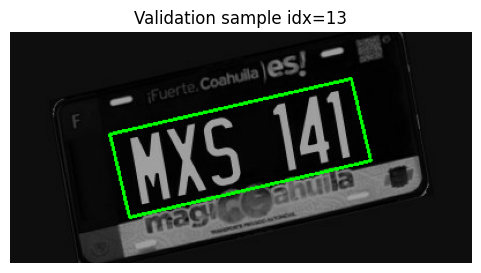

In [10]:
# 3) Probar mostrando una muestra aleatoria de validation
val_iter = iter(validation_dataset)
images_batch, bboxes_batch = next(val_iter)  # tensors

print("Batch shapes:", images_batch.shape, bboxes_batch.shape)
# seleccionar índice aleatorio dentro del batch (puede ser menor en el último batch)
batch_size_actual = images_batch.shape[0]
idx = random.randint(0, batch_size_actual - 1)

sample_image = images_batch[idx].numpy()   # shape (H, W, 1), float32 [0,1]
sample_bbox  = bboxes_batch[idx].numpy()   # shape (5,)

print("\nMuestra seleccionada del batch:")
print(f"  indice en batch: {idx}")
print(f"  sample_image.shape: {sample_image.shape}")
print(f"  bbox (norm): {sample_bbox}")

# 4) Dibujar y mostrar usando la función de debug (plot_sample_with_gt)
plot_sample_with_gt(sample_image, sample_bbox, title=f"Validation sample idx={idx}")

In [14]:
from tensorflow import keras
from tensorflow.keras import layers, Model

def build_optimized_box_regressor(input_shape):
    input_img = layers.Input(shape=input_shape, name="image")
    
    # La normalización puede estar aquí o en el cargador de datos.
    # Para consistencia, la mantenemos aquí.
    x = layers.Rescaling(1./255)(input_img)

    # --- CUERPO (Tus 3 bloques convolucionales, sin cambios) ---
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (75, 150, 32)
    x = layers.SpatialDropout2D(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (37, 75, 64)
    x = layers.SpatialDropout2D(0.25)(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (18, 37, 128)
    x = layers.SpatialDropout2D(0.25)(x)

    # ### CAMBIO CLAVE: Bloque de Reducción Adicional ###
    # Añadimos un bloque más profundo para reducir aún más las dimensiones espaciales.
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (9, 18, 256)
    
    # ### CAMBIO CLAVE 2: Pooling Final Agresivo ###
    # Un último pooling para compactar la información antes de aplanar.
    x = layers.MaxPooling2D((3, 3))(x) # Shape -> (3, 6, 256)
    
    # --- CABEZA DE REGRESIÓN ---
    # Ahora aplanamos un vector mucho más pequeño
    x = layers.Flatten()(x) # Shape -> (4608,)    
    #x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    
    # Las capas densas ahora son mucho más ligeras y eficientes
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Capa de salida para regresión (5 valores)
    outputs = layers.Dense(5, activation="linear", name="box_output")(x)
    
    model = Model(inputs=input_img, outputs=outputs, name="optimized_box_regressor")
    
    # Compilación para regresión (sin cambios)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# --- Construir y mostrar el nuevo modelo ---
optimized_model = build_optimized_box_regressor(
    input_shape=(200, 400, 1)
)
optimized_model.summary()

Model: "optimized_box_regressor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 200, 400, 1)]     0         
                                                                 
 rescaling_2 (Rescaling)     (None, 200, 400, 1)       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 200, 400, 32)      320       
                                                                 
 batch_normalization_16 (Bat  (None, 200, 400, 32)     128       
 chNormalization)                                                
                                                                 
 conv2d_15 (Conv2D)          (None, 200, 400, 32)      9248      
                                                                 
 batch_normalization_17 (Bat  (None, 200, 400, 32)     128       
 chNormalization)                          

In [8]:
import json, os
bad = []
for js in all_json_paths:   # asumo que ya tienes esta lista (si no, usa get_image_paths_and_json_paths)
    try:
        with open(js, 'r', encoding='utf-8') as f:
            txt = f.read()
            if txt.strip() == "":
                bad.append((js, "EMPTY"))
                continue
            json.loads(txt)
    except Exception as e:
        bad.append((js, str(e)))

print(f"Archivos JSON problemáticos encontrados: {len(bad)}")
if bad:
    for p,err in bad[:30]:
        print(p, " -> ", err)


Archivos JSON problemáticos encontrados: 0


In [15]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

# --- Crear el modelo (asumiendo que la función ya está definida) ---
#detector_model = build_oriented_object_detector()

# --- Hiperparámetros de Entrenamiento ---
EPOCHS = 50
CHECKPOINT_FILEPATH = 'best_box_CNN_detector_model_v4.keras' # Usar la extensión .keras es lo más moderno

# --- Callback para guardar el mejor modelo ---
# 1. 'monitor': La métrica que queremos observar. Usaremos la MAE en el conjunto de validación.
# 2. 'mode': 'min' porque queremos que la MAE sea lo más baja posible.
# 3. 'save_best_only': True para que solo guarde el modelo cuando la métrica monitoreada mejore.
# 4. 'verbose': 1 para que te notifique en la consola cada vez que guarda un nuevo mejor modelo.
checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_FILEPATH,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    verbose=1
)

print(f"\n--- Iniciando entrenamiento por {EPOCHS} épocas ---")
print(f"El mejor modelo se guardará en: {CHECKPOINT_FILEPATH}")

# --- Entrenamiento del modelo ---
# Ahora incluimos 'validation_data' y 'callbacks'
history = optimized_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset, # <-- AÑADIDO
    callbacks=[checkpoint_callback]      # <-- AÑADIDO
)

print("\n--- Entrenamiento completado ---")

# --- Cargar el mejor modelo guardado (opcional) ---
print(f"Cargando el mejor modelo guardado desde {CHECKPOINT_FILEPATH} para evaluación final...")
best_model = tf.keras.models.load_model(CHECKPOINT_FILEPATH)

# --- Evaluar el mejor modelo en el set de validación ---
print("\nEvaluando el rendimiento del MEJOR modelo en el set de validación:")
val_loss, val_mae = best_model.evaluate(validation_dataset)
print(f"Pérdida final (Loss): {val_loss:.4f}")
print(f"Error Absoluto Medio final (MAE): {val_mae:.4f}")


--- Iniciando entrenamiento por 50 épocas ---
El mejor modelo se guardará en: best_box_CNN_detector_model_v4.keras
Epoch 1/50
212/212 [==============================] - ETA: 0s - loss: 0.7945 - mae: 0.6185
Epoch 1: val_mae improved from inf to 0.10361, saving model to best_box_CNN_detector_model_v4.keras
212/212 [==============================] - 155s 665ms/step - loss: 0.7945 - mae: 0.6185 - val_loss: 0.0192 - val_mae: 0.1036
Epoch 2/50
212/212 [==============================] - ETA: 0s - loss: 0.1549 - mae: 0.2737
Epoch 2: val_mae did not improve from 0.10361
212/212 [==============================] - 128s 596ms/step - loss: 0.1549 - mae: 0.2737 - val_loss: 4.1957 - val_mae: 1.5625
Epoch 3/50
212/212 [==============================] - ETA: 0s - loss: 0.0612 - mae: 0.1696
Epoch 3: val_mae improved from 0.10361 to 0.08397, saving model to best_box_CNN_detector_model_v4.keras
212/212 [==============================] - 131s 608ms/step - loss: 0.0612 - mae: 0.1696 - val_loss: 0.0147 - va

In [16]:
from tensorflow import keras
from tensorflow.keras import layers, Model

def build_optimized_box_regressor(input_shape):
    input_img = layers.Input(shape=input_shape, name="image")
    
    # La normalización puede estar aquí o en el cargador de datos.
    # Para consistencia, la mantenemos aquí.
    x = layers.Rescaling(1./255)(input_img)

    # --- CUERPO (Tus 3 bloques convolucionales, sin cambios) ---
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (75, 150, 32)
    x = layers.SpatialDropout2D(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (37, 75, 64)
    x = layers.SpatialDropout2D(0.25)(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (18, 37, 128)
    x = layers.SpatialDropout2D(0.25)(x)

    # ### CAMBIO CLAVE: Bloque de Reducción Adicional ###
    # Añadimos un bloque más profundo para reducir aún más las dimensiones espaciales.
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (9, 18, 256)
    
    # ### CAMBIO CLAVE 2: Pooling Final Agresivo ###
    # Un último pooling para compactar la información antes de aplanar.
    x = layers.MaxPooling2D((3, 3))(x) # Shape -> (3, 6, 256)
    
    # --- CABEZA DE REGRESIÓN ---
    # Ahora aplanamos un vector mucho más pequeño
    x = layers.Flatten()(x) # Shape -> (4608,)    
    #x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    
    # Las capas densas ahora son mucho más ligeras y eficientes
    x = layers.Dense(512, activation='relu')(x)    
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    
    # Capa de salida para regresión (5 valores)
    outputs = layers.Dense(5, activation="linear", name="box_output")(x)
    
    model = Model(inputs=input_img, outputs=outputs, name="optimized_box_regressor")
    
    # Compilación para regresión (sin cambios)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# --- Construir y mostrar el nuevo modelo ---
optimized_model = build_optimized_box_regressor(
    input_shape=(200, 400, 1)
)
optimized_model.summary()

Model: "optimized_box_regressor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 200, 400, 1)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 200, 400, 1)       0         
                                                                 
 conv2d_21 (Conv2D)          (None, 200, 400, 32)      320       
                                                                 
 batch_normalization_24 (Bat  (None, 200, 400, 32)     128       
 chNormalization)                                                
                                                                 
 conv2d_22 (Conv2D)          (None, 200, 400, 32)      9248      
                                                                 
 batch_normalization_25 (Bat  (None, 200, 400, 32)     128       
 chNormalization)                          

In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

# --- Crear el modelo (asumiendo que la función ya está definida) ---
#detector_model = build_oriented_object_detector()

# --- Hiperparámetros de Entrenamiento ---
EPOCHS = 50
CHECKPOINT_FILEPATH = 'best_box_CNN_detector_model_v5.keras' # Usar la extensión .keras es lo más moderno

# --- Callback para guardar el mejor modelo ---
# 1. 'monitor': La métrica que queremos observar. Usaremos la MAE en el conjunto de validación.
# 2. 'mode': 'min' porque queremos que la MAE sea lo más baja posible.
# 3. 'save_best_only': True para que solo guarde el modelo cuando la métrica monitoreada mejore.
# 4. 'verbose': 1 para que te notifique en la consola cada vez que guarda un nuevo mejor modelo.
checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_FILEPATH,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    verbose=1
)

print(f"\n--- Iniciando entrenamiento por {EPOCHS} épocas ---")
print(f"El mejor modelo se guardará en: {CHECKPOINT_FILEPATH}")

# --- Entrenamiento del modelo ---
# Ahora incluimos 'validation_data' y 'callbacks'
history = optimized_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset, # <-- AÑADIDO
    callbacks=[checkpoint_callback]      # <-- AÑADIDO
)

print("\n--- Entrenamiento completado ---")

# --- Cargar el mejor modelo guardado (opcional) ---
print(f"Cargando el mejor modelo guardado desde {CHECKPOINT_FILEPATH} para evaluación final...")
best_model = tf.keras.models.load_model(CHECKPOINT_FILEPATH)

# --- Evaluar el mejor modelo en el set de validación ---
print("\nEvaluando el rendimiento del MEJOR modelo en el set de validación:")
val_loss, val_mae = best_model.evaluate(validation_dataset)
print(f"Pérdida final (Loss): {val_loss:.4f}")
print(f"Error Absoluto Medio final (MAE): {val_mae:.4f}")


--- Iniciando entrenamiento por 50 épocas ---
El mejor modelo se guardará en: best_box_CNN_detector_model_v5.keras
Epoch 1/50
212/212 [==============================] - ETA: 0s - loss: 0.3241 - mae: 0.3940
Epoch 1: val_mae improved from inf to 0.27248, saving model to best_box_CNN_detector_model_v5.keras
212/212 [==============================] - 132s 606ms/step - loss: 0.3241 - mae: 0.3940 - val_loss: 0.1533 - val_mae: 0.2725
Epoch 2/50
212/212 [==============================] - ETA: 0s - loss: 0.0399 - mae: 0.1505
Epoch 2: val_mae did not improve from 0.27248
212/212 [==============================] - 130s 602ms/step - loss: 0.0399 - mae: 0.1505 - val_loss: 25.8297 - val_mae: 4.5150
Epoch 3/50
212/212 [==============================] - ETA: 0s - loss: 0.0168 - mae: 0.0978
Epoch 3: val_mae did not improve from 0.27248
212/212 [==============================] - 130s 602ms/step - loss: 0.0168 - mae: 0.0978 - val_loss: 3.0803 - val_mae: 1.0073
Epoch 4/50
212/212 [=======================

In [10]:
# --- Evaluación (opcional) ---
# Si tienes un dataset de prueba
# test_loss, test_mae = detector_model.evaluate(test_dataset)
# print(f"Pérdida en el conjunto de prueba: {test_loss:.4f}")
# print(f"MAE en el conjunto de prueba: {test_mae:.4f}")

# --- Predicción de ejemplo (opcional) ---
# Puedes tomar una imagen del dataset para predecir
for image_batch, true_bbox_batch in train_dataset.take(1):
    sample_image = image_batch[0:1] # Tomar la primera imagen del batch
    true_bbox = true_bbox_batch[0].numpy()
    
    predicted_bbox = best_model.predict(sample_image)[0]
    
    print("\n--- Ejemplo de Predicción ---")
    print(f"Imagen original (shape): {sample_image.shape}")
    print(f"Bounding Box REAL (x,y,w,h,theta): {true_bbox}")
    print(f"Bounding Box PREDICHA (x,y,w,h,theta): {predicted_bbox}")

1/1 [==============================] - 0s 161ms/step

--- Ejemplo de Predicción ---
Imagen original (shape): (1, 150, 300, 1)
Bounding Box REAL (x,y,w,h,theta): [ 0.664119    0.666388    1.034899    0.65091294 -0.28892606]
Bounding Box PREDICHA (x,y,w,h,theta): [ 0.66214395  0.6678426   1.0748353   0.6564209  -0.302981  ]


In [9]:
# --- Cargar el mejor modelo guardado (opcional) ---
print(f"Cargando el mejor modelo guardado desde {CHECKPOINT_FILEPATH} para evaluación final...")
best_model = tf.keras.models.load_model(CHECKPOINT_FILEPATH)

# --- Evaluar el mejor modelo en el set de validación ---
print("\nEvaluando el rendimiento del MEJOR modelo en el set de validación:")
val_loss, val_mae = best_model.evaluate(validation_dataset)
print(f"Pérdida final (Loss): {val_loss:.4f}")
print(f"Error Absoluto Medio final (MAE): {val_mae:.4f}")

Cargando el mejor modelo guardado desde best_box_CNN_detector_model_v3.keras para evaluación final...

Evaluando el rendimiento del MEJOR modelo en el set de validación:
95/95 [==============================] - 8s 66ms/step - loss: 0.0020 - mae: 0.0286
Pérdida final (Loss): 0.0020
Error Absoluto Medio final (MAE): 0.0286


1/1 [==============================] - 0s 17ms/step

         Comparación Numérica de Bounding Box
            x_center   y_center      width     height      angle
Real:         0.4976     0.5009     0.6227     0.2544    -0.1326
Predicha:     0.4987     0.5014     0.6462     0.2733    -0.1292



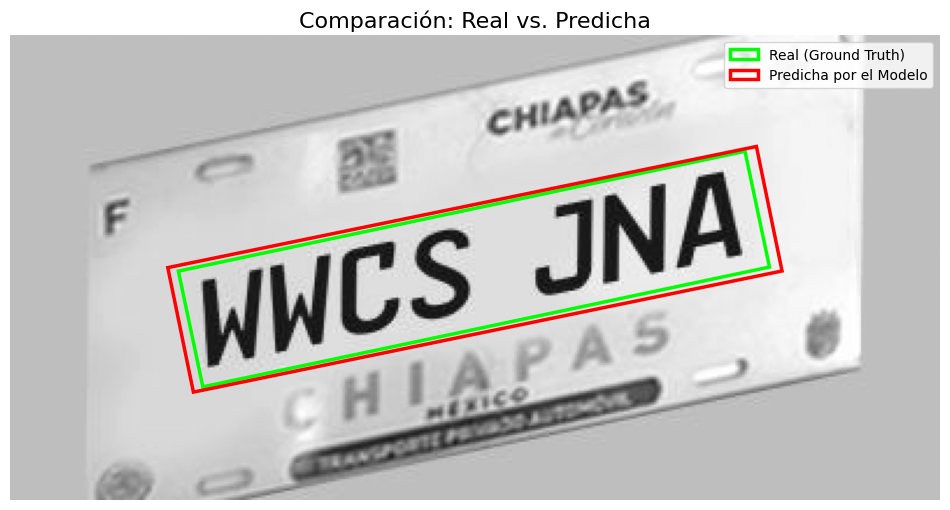

In [73]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import os

# ==============================================================================
#  2. CARGAR EL MODELO ENTRENADO
# ==============================================================================
MODEL_PATH = 'best_box_CNN_detector_model_v5.keras'

# ==============================================================================
#  3. FUNCIÓN DE VISUALIZACIÓN (sin cambios)
# ==============================================================================
def plot_prediction(image, true_bbox, predicted_bbox):
    fig, ax = plt.subplots(1, figsize=(12, 7))
    ax.imshow(image[:, :, 0], cmap='gray')
    
    def draw_bbox(bbox, color, label):
        h_img, w_img, _ = image.shape
        center_x, center_y, width, height = bbox[0] * w_img, bbox[1] * h_img, bbox[2] * w_img, bbox[3] * h_img
        angle_rad = bbox[4] * (math.pi / 2)
        
        corners_unrotated = np.array([
            [-width / 2, -height / 2], [+width / 2, -height / 2],
            [+width / 2, +height / 2], [-width / 2, +height / 2]
        ])
        c, s = np.cos(-angle_rad), np.sin(-angle_rad)
        rotation_matrix = np.array([[c, -s], [s, c]])
        rotated_corners = corners_unrotated.dot(rotation_matrix)
        translated_corners = rotated_corners + np.array([center_x, center_y])
        
        polygon = patches.Polygon(translated_corners, linewidth=2.5, edgecolor=color, facecolor='none', label=label)
        ax.add_patch(polygon)

    draw_bbox(true_bbox, 'lime', 'Real (Ground Truth)')
    draw_bbox(predicted_bbox, 'red', 'Predicha por el Modelo')
    
    ax.set_title("Comparación: Real vs. Predicha", fontsize=16)
    ax.axis('off')
    ax.legend()
    plt.show()

# ==============================================================================
#  4. REALIZAR Y VISUALIZAR UNA PREDICCIÓN
# ==============================================================================
if best_model:
    try:
        # Asumimos que 'validation_dataset' ya existe de las celdas anteriores
        image_batch, true_bbox_batch = next(iter(validation_dataset))
        idx = np.random.randint(0, image_batch.shape[0])
        sample_image = image_batch[idx]
        true_bbox = true_bbox_batch[idx].numpy()
        
        image_for_prediction = np.expand_dims(sample_image, axis=0)
        predicted_bbox = best_model.predict(image_for_prediction)[0]
        
        print("\n" + "="*50)
        print("         Comparación Numérica de Bounding Box")
        print("="*50)
        print(f"          {'x_center':>10} {'y_center':>10} {'width':>10} {'height':>10} {'angle':>10}")
        print(f"Real:     {true_bbox[0]:10.4f} {true_bbox[1]:10.4f} {true_bbox[2]:10.4f} {true_bbox[3]:10.4f} {true_bbox[4]:10.4f}")
        print(f"Predicha: {predicted_bbox[0]:10.4f} {predicted_bbox[1]:10.4f} {predicted_bbox[2]:10.4f} {predicted_bbox[3]:10.4f} {predicted_bbox[4]:10.4f}")
        print("="*50 + "\n")

        plot_prediction(sample_image.numpy(), true_bbox, predicted_bbox)

    except NameError:
        print("ERROR: El 'validation_dataset' no está definido. Asegúrate de haberlo creado.")
    except Exception as e:
        print(f"Ocurrió un error durante la predicción o visualización: {e}")

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2  # Importamos OpenCV
import math
import os

# --- 1. Cargar el Modelo Entrenado ---
MODEL_PATH = 'best_box_CNN_detector_model_v5.keras' # Asegúrate que sea el path correcto

try:
    print(f"Cargando el modelo desde: {MODEL_PATH}")
    best_model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={'Patches': Patches} # Necesario si tu modelo CNN usa esta capa
    )
    print("Modelo cargado exitosamente. ✅")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    best_model = None

# --- 2. Función para Recortar y Enderezar la Caja ---
def crop_oriented_rect(image, bbox):
    """
    Usa OpenCV para recortar y enderezar la región definida por una caja orientada.
    """
    # Denormalizar valores
    h_img, w_img, _ = image.shape
    center_x = bbox[0] * w_img
    center_y = bbox[1] * h_img
    width = int(bbox[2] * w_img)
    height = int(bbox[3] * h_img)
    angle_rad = bbox[4] * (math.pi / 2)

    # Calcular las 4 esquinas de la caja en la imagen original (puntos fuente)
    corners_unrotated = np.array([
        [-width / 2, -height / 2], [+width / 2, -height / 2],
        [+width / 2, +height / 2], [-width / 2, +height / 2]
    ])
    c, s = np.cos(-angle_rad), np.sin(-angle_rad)
    rotation_matrix = np.array([[c, -s], [s, c]])
    source_corners = corners_unrotated.dot(rotation_matrix) + np.array([center_x, center_y])
    
    # Definir las 4 esquinas de la imagen de destino (un rectángulo perfecto)
    dest_corners = np.array([
        [0, 0], [width - 1, 0],
        [width - 1, height - 1], [0, height - 1]
    ], dtype="float32")

    # Calcular la matriz de transformación de perspectiva
    transform_matrix = cv2.getPerspectiveTransform(source_corners.astype("float32"), dest_corners)

    # Aplicar la transformación para "enderezar" el recorte
    warped_image = cv2.warpPerspective(image, transform_matrix, (width, height))
    
    return warped_image

# --- 3. Realizar y Visualizar una Predicción ---
if best_model:
    try:
        # Asumimos que 'validation_dataset' existe de las celdas anteriores
        image_batch, true_bbox_batch = next(iter(validation_dataset))
        idx = np.random.randint(0, image_batch.shape[0])
        
        sample_image = image_batch[idx].numpy()
        true_bbox = true_bbox_batch[idx].numpy()
        
        # El modelo espera un batch, así que añadimos una dimensión
        image_for_prediction = np.expand_dims(sample_image, axis=0)
        predicted_bbox = best_model.predict(image_for_prediction)[0]
        
        # --- Imprimir comparación numérica (sin cambios) ---
        print("\n" + "="*50)
        print("         Comparación Numérica de Bounding Box")
        print("="*50)
        print(f"          {'x_center':>10} {'y_center':>10} {'width':>10} {'height':>10} {'angle':>10}")
        print(f"Real:     {true_bbox[0]:10.4f} {true_bbox[1]:10.4f} {true_bbox[2]:10.4f} {true_bbox[3]:10.4f} {true_bbox[4]:10.4f}")
        print(f"Predicha: {predicted_bbox[0]:10.4f} {predicted_bbox[1]:10.4f} {predicted_bbox[2]:10.4f} {predicted_bbox[3]:10.4f} {predicted_bbox[4]:10.4f}")
        print("="*50 + "\n")

        # --- Generar y mostrar los recortes ---
        true_crop = crop_oriented_rect(sample_image, true_bbox)
        predicted_crop = crop_oriented_rect(sample_image, predicted_bbox)

        # Crear la figura para mostrar ambos recortes
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Comparación de Recortes Enderezados', fontsize=16)

        # Recorte Real (Ground Truth)
        axes[0].imshow(true_crop, cmap='gray')
        axes[0].set_title('Recorte Real (Ground Truth)', fontsize=12)
        axes[0].axis('off')

        # Recorte Predicho
        axes[1].imshow(predicted_crop, cmap='gray')
        axes[1].set_title('Recorte Predicho por el Modelo', fontsize=12)
        axes[1].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    except NameError:
        print("ERROR: El 'validation_dataset' no está definido. Asegúrate de haberlo creado.")
    except Exception as e:
        print(f"Ocurrió un error durante la predicción o visualización: {e}")

Cargando el modelo desde: best_box_CNN_detector_model_v5.keras
Error al cargar el modelo: name 'Patches' is not defined


Cargando el modelo desde: best_box_CNN_detector_model_v5.keras
Modelo cargado exitosamente. ✅

         Comparación Numérica de Bounding Box
            x_center   y_center      width     height      angle
Real:         0.4991     0.4982     0.7594     0.4207     0.2338
Predicha:     0.5011     0.4987     0.8094     0.4489     0.2282



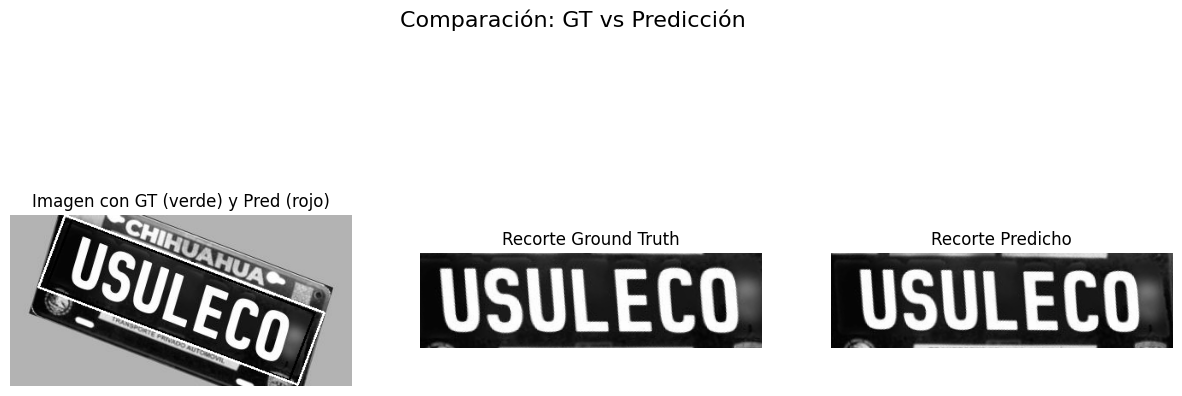

In [63]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math
import os

# --- 1. Cargar el Modelo Entrenado ---
MODEL_PATH = 'best_box_CNN_detector_model_v5.keras'

try:
    print(f"Cargando el modelo desde: {MODEL_PATH}")
    best_model = tf.keras.models.load_model(MODEL_PATH)
    print("Modelo cargado exitosamente. ✅")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    best_model = None

# --- 2. Funciones corregidas ---

def get_corners_from_bbox(bbox, image_shape, angle_mapping="pi/2"):
    """
    Convierte bbox = [x_center, y_center, width, height, angle_norm] (normalizados)
    a 4 esquinas en coordenadas de píxel (orden: tl, tr, br, bl).
    - image_shape: (H, W, C)
    - angle_mapping: cómo mapear el valor normalizado del ángulo a radianes.
      Por defecto mapea a [-pi/2, pi/2] (angle_norm * pi/2). Ajusta si tu dataset usa otra convención.
    """
    h_img, w_img = image_shape[0], image_shape[1]
    eps = 1e-6

    # Clamping / sanity
    x_n = float(np.clip(bbox[0], 0.0, 1.0))
    y_n = float(np.clip(bbox[1], 0.0, 1.0))
    w_n = float(np.clip(bbox[2], eps, 1.0))
    h_n = float(np.clip(bbox[3], eps, 1.0))
    a_n = float(bbox[4])

    # Denormalizar
    cx = x_n * w_img
    cy = y_n * h_img
    width = w_n * w_img
    height = h_n * h_img

    # Mapear ángulo normalizado a radianes
    # Por convención asumimos angle_norm in [-1,1] -> [-pi/2, pi/2]
    if angle_mapping == "pi/2":
        angle_rad = a_n * (math.pi / 2.0)
    else:
        angle_rad = a_n  # si ya viene en radianes

    # Definimos esquinas relativas (fila = punto [x,y])
    corners_unrotated = np.array([
        [-width / 2.0, -height / 2.0],  # tl
        [ width / 2.0, -height / 2.0],  # tr
        [ width / 2.0,  height / 2.0],  # br
        [-width / 2.0,  height / 2.0]   # bl
    ], dtype=np.float32)

    # Matriz de rotación estándar (para ángulo 'angle_rad')
    cos_a = math.cos(angle_rad)
    sin_a = math.sin(angle_rad)
    R = np.array([[cos_a, -sin_a],
                  [sin_a,  cos_a]], dtype=np.float32)

    # corners_unrotated son filas [x,y], así que aplicamos la rotación con R^T:
    # rotated_rows = (R @ v_col).T  -> equivalente a v_row @ R.T
    rotated = corners_unrotated @ R.T

    # trasladar al centro
    translated = rotated + np.array([cx, cy], dtype=np.float32)

    return translated.astype(np.float32)  # shape (4,2) - order: tl,tr,br,bl


def crop_and_warp_image(image, corners, target_width, target_height):
    """
    Recorta la región indicada por 'corners' (4x2) y la transforma a un rectángulo
    de tamaño (target_width, target_height).
    corners debe estar en el orden: tl, tr, br, bl (coincide con dest_corners abajo).
    """
    # Asegurar tipo y rango para OpenCV
    if image.dtype != np.uint8:
        img_uint8 = (np.clip(image, 0.0, 1.0) * 255.0).astype(np.uint8)
    else:
        img_uint8 = image

    src = np.array(corners, dtype=np.float32)
    if src.shape != (4, 2):
        raise ValueError("Corners debe ser array de forma (4,2).")

    dest = np.array([
        [0, 0],
        [target_width - 1, 0],
        [target_width - 1, target_height - 1],
        [0, target_height - 1]
    ], dtype=np.float32)

    # componer la matriz y warp
    M = cv2.getPerspectiveTransform(src, dest)
    warped = cv2.warpPerspective(img_uint8, M, (int(target_width), int(target_height)))
    return warped


def draw_box_on_image(image, corners, color=(0,255,0), thickness=2):
    """
    Dibuja un polígono con las esquinas sobre la imagen (retorna copia).
    corners orden tl,tr,br,bl
    """
    img = image.copy()
    if img.dtype != np.uint8:
        img = (np.clip(img,0.0,1.0)*255).astype(np.uint8)
    pts = np.array(corners, dtype=np.int32).reshape((-1,1,2))
    cv2.polylines(img, [pts], isClosed=True, color=color, thickness=thickness)
    return img

# --- 3. Predicción y visualización ---
# Asegúrate de tener 'validation_dataset' definido (como en tu notebook).
image_batch, true_bbox_batch = next(iter(validation_dataset))
idx = np.random.randint(0, image_batch.shape[0])

sample_image = image_batch[idx].numpy()  # float [0,1] o uint8
true_bbox = true_bbox_batch[idx].numpy()

# Predecir
image_for_prediction = np.expand_dims(sample_image, axis=0)
predicted_bbox = best_model.predict(image_for_prediction, verbose=0)[0]

# Imprimir comparación numérica
print("\n" + "="*50)
print("         Comparación Numérica de Bounding Box")
print("="*50)
print(f"          {'x_center':>10} {'y_center':>10} {'width':>10} {'height':>10} {'angle':>10}")
print(f"Real:     {true_bbox[0]:10.4f} {true_bbox[1]:10.4f} {true_bbox[2]:10.4f} {true_bbox[3]:10.4f} {true_bbox[4]:10.4f}")
print(f"Predicha: {predicted_bbox[0]:10.4f} {predicted_bbox[1]:10.4f} {predicted_bbox[2]:10.4f} {predicted_bbox[3]:10.4f} {predicted_bbox[4]:10.4f}")
print("="*50 + "\n")

# Convertir a esquinas
true_corners = get_corners_from_bbox(true_bbox, sample_image.shape)
pred_corners = get_corners_from_bbox(predicted_bbox, sample_image.shape)

# Denormalizar tamaños para el warp (usar max(1,...) para evitar 0)
true_w = max(1, int(round(true_bbox[2] * sample_image.shape[1])))
true_h = max(1, int(round(true_bbox[3] * sample_image.shape[0])))
pred_w = max(1, int(round(predicted_bbox[2] * sample_image.shape[1])))
pred_h = max(1, int(round(predicted_bbox[3] * sample_image.shape[0])))

# Recortes
true_crop = crop_and_warp_image(sample_image, true_corners, true_w, true_h)
pred_crop = crop_and_warp_image(sample_image, pred_corners, pred_w, pred_h)

# Visualizar recortes y la imagen con cajas superpuestas
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Comparación: GT vs Predicción', fontsize=16)

# Imagen original con overlays
overlay_img = draw_box_on_image(sample_image, true_corners, color=(0,255,0), thickness=2)
overlay_img = draw_box_on_image(overlay_img, pred_corners, color=(255,0,0), thickness=2)
axes[0].imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen con GT (verde) y Pred (rojo)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(true_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title('Recorte Ground Truth')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(pred_crop, cv2.COLOR_BGR2RGB))
axes[2].set_title('Recorte Predicho')
axes[2].axis('off')

plt.show()
